In [54]:
import torch #for creating tensors to store all numerical values including parameters of NN but also raw data
import torch.nn as nn #making weights and biases tensors part of a NN
import torch.nn.functional as F #gives activation functions
from torch.optim import SGD #stochastic gradient descent to fit NN to the data

Add Lightning imports. Let load this wrapper to make training easier to code!

In [74]:
import pytorch_lightning as L

Dataset & Dataloader are essential for working with larger datasets.

In [56]:
from torch.utils.data import TensorDataset, DataLoader

For plotting

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

## create pre-trained class containing (already set) weights and biases & for running the data through (forward) the NN but this time with Lightning

Now, the creation of the class and inheriting from lib's module happend for lightning. The BasicLightning cumtom class needs to inherit from L.LightningModule instead of just torch's nn.Module.

In [58]:
class BasicLightning(L.LightningModule):
    # 1 create initalization method & call initialization method from the parent class L.LightningModule
    def __init__(self):
        super().__init__() 
        # 2 create & initialize weights and biases in our NN (from quest's example that are alredy set)
        # make sure to use nn.Parameters and torch.tensors to ensure acceleratec arithmetic & automatic differentiation that it provides
        # w00 doesn't need to be optimized by SGD, that's why requires_grad is set to False
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad = False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad = False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad = False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad = False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad = False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad = False)

        self.final_bias = nn.Parameter(torch.tensor(-16.), requires_grad = False)
        #created parameters for each weight & bias

    #3 now the parameters need to be connected to the input, activation functions and ultimately the output = FORWARD PASS
    # takes input value and calculate the output value with weights, biases and activation functions (here relu() )
    def forward(self, input):
        #connect input to the activation function on top
        input_to_top_relu = input * self.w00 + self.b00
        #pass input to the top relu activation function
        top_relu_output = F.relu(input_to_top_relu)
        #scale relu output by the w01
        scaled_top_relu_output = top_relu_output * self.w01

        #likewise for the bottom
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)
        return output

Let's test the BasicLightning with checking the squiggle we already know from the example

In [59]:
input_doses = torch.linspace(start = 0, end = 1, steps = 11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [60]:
model = BasicLightning() #model is a standard variable name used when coding in PyTorch, also with Lightning

In [61]:
output_values = model(input_doses) #by default calls the forward method

Text(0, 0.5, 'Effectiveness')

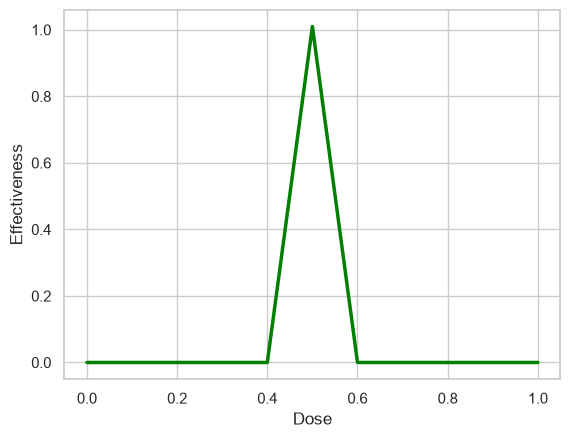

In [62]:
sns.set_theme(style = "whitegrid")
sns.lineplot(x = input_doses, #type:ignore
             y = output_values, 
             color = "green",
             linewidth = 2.5)
plt.xlabel("Dose")
plt.ylabel("Effectiveness")

The graph for BasicLightning shows effectiveness = 1 when the dose = 0.5 [correct].

In the pure PyTorch example, the code for initializing weights and biases & forward method was separate (in nn.BasicNN_train class) and the block of code for training (including setting optimizer, running the code in epochs and iterating with for loop throughout datapoints) was separate, not included in class. 

While using PyTorch + Lightning all of the code relating to the neural network is put in the same place - the L.BasicLightningTrain class!

In [110]:
class BasicLightningTrain(L.LightningModule):
    # 1 create initalization method & call initialization method from the parent class L.LightningModule
    def __init__(self):
        super().__init__() 
        # 2 create & initialize weights and biases in our NN (from quest's example that are alredy set)
        # make sure to use nn.Parameters and torch.tensors to ensure acceleratec arithmetic & automatic differentiation that it provides
        # w00 doesn't need to be optimized by SGD, that's why requires_grad is set to False
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad = False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad = False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad = False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad = False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad = False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad = False)

        self.final_bias = nn.Parameter(torch.tensor(0.), requires_grad = True) #trainable
        #created parameters for each weight & bias, all are stored under self.parameters()
        #we'll use the Lightning function to improve lr for us, we add lr as a variable
        #the value is just a placeholder and does not matter right now
        self.learning_rate = 0.01 #this is not a nn.Parameter!

    #3 now the parameters need to be connected to the input, activation functions and ultimately the output = FORWARD PASS
    # takes input value and calculate the output value with weights, biases and activation functions (here relu() )
    def forward(self, input):
        #connect input to the activation function on top
        input_to_top_relu = input * self.w00 + self.b00
        #pass input to the top relu activation function
        top_relu_output = F.relu(input_to_top_relu)
        #scale relu output by the w01
        scaled_top_relu_output = top_relu_output * self.w01

        #likewise for the bottom
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)
        return output
    # 4 set up the algorithm to use to optimize NN
    def configure_optimizers(self):
        return SGD(self.parameters(), lr = self.learning_rate) #the lr variable will be improved (not hardcoded as one value)

    # 5 perform forward pass on the batch and calculate the loss (here still SR)
    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i) #method forward() needs to be called, because we are still in class code
        loss = (output_i - label_i) ** 2
        return loss

## let's check the untrained BasicLightningTrain (that it's not on point)

In [ ]:
## NOTE: Because we have so little data, and let's be honest, it's an unrealistically small 
## amount of data, the learning rate algorithm, lr_find(), that we use in the next section has trouble. 
## So, the point here is to show how to use lr_find() when you have a reasonable amount of data, 
## which we fake here by making 100 copies of the inputs and labels.

In [138]:
inputs = torch.tensor([0., 0.5, 1.] * 100)
labels = torch.tensor([0., 1., 0.] * 100) #observed output values

In [139]:
model = BasicLightningTrain()
outputs_values = model(inputs)

Text(0, 0.5, 'Effectiveness')

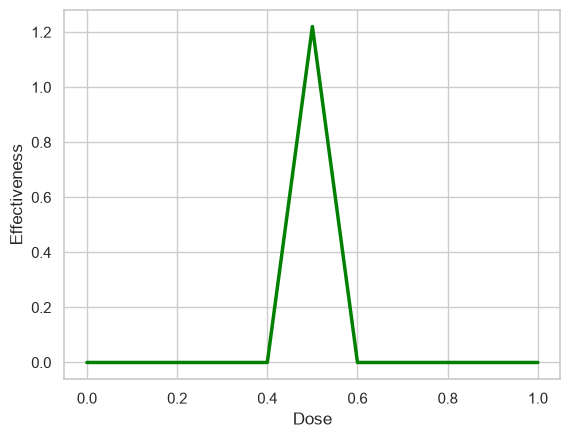

In [140]:
sns.set_theme(style = "whitegrid")
sns.lineplot(
    x=input_doses, #type:ignore
    y=output_values.detach(), #seaborn doesn't know what to do with the gradent so it needs to be stripped off with detach
    color="green",
    linewidth=2.5
)
plt.xlabel("Dose")
plt.ylabel("Effectiveness")

## let's train the BasicLightningTrain NN

Now that the Lightning is used, the training data needs to be **wrapped in a DataLoader**!
Dataloaders:
* make it easy to access the data in batches
* make it easy to suffle the data each epoch
* make it easy to use a relatively small fraction of the data if we want to do a quick and dirty training for debugging

In [ ]:
## If we want to use Lightning for training, then we have to pass the Trainer the data wrapped in 
## something called a DataLoader. DataLoaders provide a handful of nice features including...
##   1) They can access the data in minibatches instead of all at once. In other words,
##      The DataLoader doesn't need us to load all of the data into memory first. Instead
##      it just loads what it needs in an efficient way. This is crucial for large datasets.
##   2) They can reshuffle the data every epoch to reduce model overfitting
##   3) We can easily just use a fraction of the data if we want do a quick train

In [141]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

The graph for untrained BasicNN_train shows effectiveness = 17 when dose = 0.5 [too high, incorrect]

Then a change - we crate a Ligthning Trainer, which will first be used to find a good value for the learning rate and then to train (optimize) the model.

Now we have the knowledge from starter example, than 34 epochs is enough to fit model to teh data. BUT if it were not, the good news is that we don't need to start from zero and train again, bacause Lightning lets us ADD aditional epochs right where we left off!! (wow)

Lightning automatically detect if GPUs are avaliable by setting accelerator = "auto".
Lightning detects how many GPUs are avaliable ny setting devices = "auto".

In [142]:
trainer = L.Trainer(max_epochs = 34, accelerator = "auto", devices = "auto")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Now, a module tuner.lr_find() needs to be called to find an improved learning rate. By default, lr_find() will create 100 candidate laerning rates between the minimum and the maximum values, and, by setting early_stop_threshold = None, we will test them all.

In [143]:
model = BasicLightningTrain()
tuner = L.tuner.Tuner(trainer) #type:ignore
# newer api than in quest with separate Tuner class
lr_find_results = tuner.lr_find(model,
                                train_dataloaders = dataloader,
                                min_lr = 0.001,
                                max_lr = 1.0,
                                early_stop_threshold = None)
new_lr = lr_find_results.suggestion() #access the improved lr

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
/Users/Maja/PRIVATE-PROJECTS/ML_for_Neuroscience/dl_venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/Maja/PRIVATE-PROJECTS/ML_for_Neuroscience/dl_venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
Finding best initial lr: 100%|██████████| 100/100 [00:00<00:00, 729.16it/s]
Restoring states from the checkpoint path at /Users/Maja/PRIVATE-PROJECTS/M

In [144]:
print(f"lr_find() suggests {new_lr:.5f} for the learning rate.")

lr_find() suggests 0.00214 for the learning rate.


Lastly, set the learning_rate variable in the model to the new_lr value. 

In [145]:
model.learning_rate = new_lr # applied improved lr for SGD!

## let's train the model with trainer

Fit() requires the model and the training data. The trainer will internally call our model's configure_optimizers() function = configuring SGD optimizer using the new learning rate that was just set to self.learning_rate. Then the trainer calls training_step function to calculate the loss. The trainer will call (without user's action) the:
* **optimizer.zero_grad()**, so that each epoch starts with fresh gradient
* **loss.backward()** to calculate the new gradient
* **optimizer.step()** to take a step towards optimal values for the parameters

Then the trainer calls training_step() again and repeats for each epoch that we requested.

In [146]:
trainer.fit(model, 
            train_dataloaders=dataloader)


  | Name         | Type | Params | Mode | FLOPs
-----------------------------------------------------
  | other params | n/a  | 7      | n/a  | n/a  
-----------------------------------------------------
1         Trainable params
6         Non-trainable params
7         Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 0:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 33: 100%|██████████| 300/300 [00:00<00:00, 765.84it/s, v_num=7]

`Trainer.fit` stopped: `max_epochs=34` reached.


Epoch 33: 100%|██████████| 300/300 [00:00<00:00, 758.74it/s, v_num=7]


In [147]:
print(model.final_bias.data)

tensor(-16.0098)
